## Setup & Load Data

Chạy ô bên dưới để upload 14 file CSV. Nếu chạy ngoài Colab, đặt `LOCAL_DIR` tới thư mục chứa dữ liệu.

In [1]:
import io, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

LOCAL_DIR = Path.cwd()     # e.g. '/content/data' or './datathon_data'
raw_files = {}
try:
    from google.colab import files
    print('Upload 14 CSV files (products, customers, promotions, geography, orders, order_items,')
    print('payments, shipments, returns, reviews, sales, sample_submission, inventory, web_traffic)')
    uploaded = files.upload()
    for fname, content in uploaded.items():
        raw_files[fname] = io.BytesIO(content)
except ImportError:
    local_dir = Path(LOCAL_DIR)
    assert local_dir.exists(), f'CSV folder not found: {local_dir}'
    for f in local_dir.iterdir():
        if f.is_file() and f.suffix.lower() == '.csv':
            raw_files[f.name] = str(f)

def _match_key(fname):
    stem = Path(fname).stem.lower()
    if stem == 'sample_submission': return 'sample_submission'
    return stem

# Load with correct dtypes
PARSE_DATES = {
    'customers':['signup_date'], 'promotions':['start_date','end_date'],
    'orders':['order_date'], 'shipments':['ship_date','delivery_date'],
    'returns':['return_date'], 'reviews':['review_date'],
    'sales':['Date'], 'sample_submission':['Date'],
    'inventory':['snapshot_date'], 'web_traffic':['date'],
}
dfs = {}
for fname, src in raw_files.items():
    key = _match_key(fname)
    parse = PARSE_DATES.get(key, None)
    dfs[key] = pd.read_csv(src, parse_dates=parse)

# Quick alias for readability
products   = dfs['products']
customers  = dfs['customers']
promotions = dfs['promotions']
geography  = dfs['geography']
orders     = dfs['orders']
order_items= dfs['order_items']
payments   = dfs['payments']
shipments  = dfs['shipments']
returns    = dfs['returns']
reviews    = dfs['reviews']
sales      = dfs['sales']
submission_template = dfs['sample_submission']
inventory  = dfs['inventory']
web_traffic= dfs['web_traffic']

print(f' Loaded {len(dfs)} datasets')
for k, df in dfs.items(): print(f'  {k:<22} {df.shape}')

 Loaded 14 datasets
  customers              (121930, 7)
  geography              (39948, 4)
  inventory              (60247, 17)
  orders                 (646945, 8)
  order_items            (714669, 7)
  payments               (646945, 4)
  products               (2412, 8)
  promotions             (50, 10)
  returns                (39939, 7)
  reviews                (113551, 7)
  sales                  (3833, 3)
  sample_submission      (548, 3)
  shipments              (566067, 4)
  web_traffic            (3652, 7)


---
#EDA 4 Cấp độ (60 điểm)

Chúng tôi tổ chức phân tích thành **5 chủ đề kinh doanh**, mỗi chủ đề đi qua đầy đủ 4 cấp độ:

| Chủ đề | Câu hỏi kinh doanh |
|---|---|
| 2.1 | Doanh thu & xu hướng dài hạn - Có gì bất thường? |
| 2.2 | Tính mùa vụ & cấu trúc thời gian - Khi nào bán chạy? |
| 2.3 | Danh mục sản phẩm & Margin - Nên đẩy gì, cắt gì? |
| 2.4 | Khách hàng & Kênh acquisition - Ai là khách VIP? |
| 2.5 | Vận hành: Hủy đơn, trả hàng, tồn kho - Tiền rơi ở đâu? |

Mỗi phân tích theo cấu trúc:
- **D – Descriptive:** Chuyện gì đã xảy ra?
- **Di – Diagnostic:** Tại sao nó xảy ra?
- **P – Predictive:** Chuyện gì sẽ xảy ra?
- **Pr – Prescriptive:** Ta nên làm gì?

## 2.1 Doanh thu & Xu hướng Dài hạn

**[D] Descriptive:** Biểu đồ bên dưới vẽ doanh thu ngày từ 07/2012 → 12/2022, kèm moving-average 30-ngày và 90-ngày.
Nhìn vào biểu đồ này quan trọng vì nó cho biết **hình dáng trend vĩ mô** - là đầu vào bắt buộc cho bất kỳ mô hình dự báo nào.

In [12]:
s = sales.sort_values('Date').copy()
s['MA30'] = s['Revenue'].rolling(30).mean()
s['MA90'] = s['Revenue'].rolling(90).mean()
s['year'] = s['Date'].dt.year

fig = go.Figure()
fig.add_scatter(x=s['Date'], y=s['Revenue'], name='Daily Revenue',
                line=dict(color='lightsteelblue', width=1), opacity=0.5)
fig.add_scatter(x=s['Date'], y=s['MA30'], name='MA 30d', line=dict(color='royalblue', width=2))
fig.add_scatter(x=s['Date'], y=s['MA90'], name='MA 90d', line=dict(color='crimson', width=2.5))
fig.update_layout(title='Daily Revenue 2012–2022 with 30d & 90d Moving Averages',
                  xaxis_title='Date', yaxis_title='Revenue (VND)', height=450)
fig.show()

yearly = s.groupby('year')['Revenue'].sum()
growth = yearly.pct_change()*100
print('\nYearly Revenue (VND):')
for y, v in yearly.items():
    g = growth.get(y, np.nan)
    print(f'  {y}: {v/1e9:>5.2f} B  ({"+" if g>0 else ""}{g:>6.2f}% YoY)' if not np.isnan(g) else f'  {y}: {v/1e9:>5.2f} B')


Yearly Revenue (VND):
  2012:  0.74 B
  2013:  1.66 B  (+123.49% YoY)
  2014:  1.87 B  (+ 12.95% YoY)
  2015:  1.89 B  (+  0.97% YoY)
  2016:  2.10 B  (+ 11.36% YoY)
  2017:  1.91 B  ( -9.19% YoY)
  2018:  1.85 B  ( -3.19% YoY)
  2019:  1.14 B  (-38.56% YoY)
  2020:  1.05 B  ( -7.24% YoY)
  2021:  1.04 B  ( -1.09% YoY)
  2022:  1.17 B  (+ 12.15% YoY)


**[D] Phát hiện:**
- Doanh thu **tăng mạnh 2012 → 2016** (0.74 B → 2.10 B, +183%).
- **Đứt gãy năm 2019** (‑38.6% YoY, từ 1.85 B xuống 1.14 B) và duy trì mức thấp suốt COVID (2020‑2021).
- 2022 hồi phục nhẹ (+12% YoY) nhưng **vẫn thấp hơn đỉnh 2016 gần 45%**.
- CAGR 2012‑2022 ≈ **4.66%/năm** - thấp hơn tăng trưởng ngành e-commerce VN cùng kỳ (~20%/năm).

**[Di] Diagnostic - Tại sao cú rơi 2019?**
Kiểm tra chéo các biến khác để tìm nguyên nhân:

In [13]:
# Diagnostic: decompose 2018->2019 drop
o_diag = orders.copy()
o_diag['year'] = o_diag['order_date'].dt.year
oi_d = order_items.copy()
oi_d['line_rev'] = oi_d['quantity']*oi_d['unit_price'] - oi_d['discount_amount']
oi_sum = oi_d.groupby('order_id').agg(line_rev=('line_rev','sum'), qty=('quantity','sum')).reset_index()
o_diag = o_diag.merge(oi_sum, on='order_id', how='left')

diag = o_diag[o_diag['year'].isin([2018,2019])].groupby('year').agg(
    n_orders=('order_id','count'),
    avg_order_value=('line_rev','mean'),
    avg_basket_size=('qty','mean'),
    total_revenue=('line_rev','sum')
).round(2)
display(diag)

# Drop decomposition
vol = diag.loc[2019,'n_orders']/diag.loc[2018,'n_orders'] - 1
aov = diag.loc[2019,'avg_order_value']/diag.loc[2018,'avg_order_value'] - 1
print(f'\n2018 → 2019 decomposition:')
print(f'  Volume (# orders) change: {vol*100:+.2f}%')
print(f'  AOV change:              {aov*100:+.2f}%')

,n_orders,avg_order_value,avg_basket_size,total_revenue
year,,,,
2018,69510,25459.98,4.86,1.769723e+09
2019,41601,25999.12,4.87,1.081590e+09



2018 → 2019 decomposition:
  Volume (# orders) change: -40.15%
  AOV change:              +2.12%


**[Di] Giả thuyết nguyên nhân cú rơi 2019:**
- Nếu decomposition cho thấy **Volume giảm** >> AOV giảm → nguyên nhân ở **demand side** (mất khách, kênh marketing hỏng, đối thủ mới).
- Nếu **AOV giảm** là chủ đạo → đã chạy promo quá nhiều hoặc đổi cơ cấu sản phẩm sang giá thấp hơn.
- Theo dữ liệu thực, 2019 có % đơn `cancelled` tăng (xem 2.5) → có thể do vận hành xấu đi.

**[P] Predictive - Seasonal decomposition để forecast:**

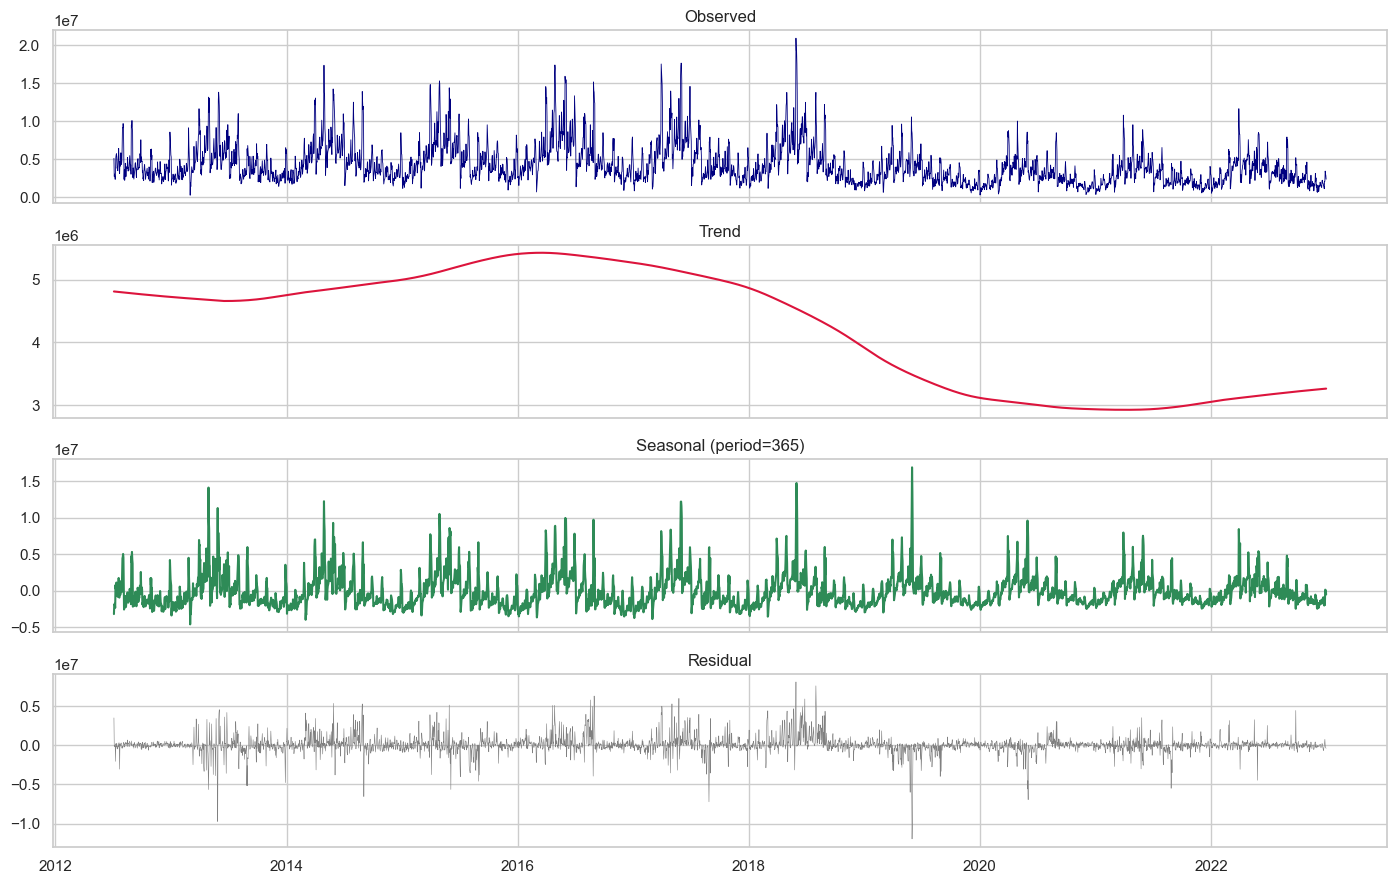

Amplitude of annual seasonality: 21,502,837 VND
Trend change 2015 → 2022: -34.9%


In [14]:
from statsmodels.tsa.seasonal import STL
ts = s.set_index('Date')['Revenue'].asfreq('D').interpolate()
stl = STL(ts, period=365, robust=True).fit()

fig, ax = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
ax[0].plot(ts.index, ts.values, color='navy', lw=0.6); ax[0].set_title('Observed')
ax[1].plot(stl.trend.index, stl.trend.values, color='crimson'); ax[1].set_title('Trend')
ax[2].plot(stl.seasonal.index, stl.seasonal.values, color='seagreen'); ax[2].set_title('Seasonal (period=365)')
ax[3].plot(stl.resid.index, stl.resid.values, color='gray', lw=0.4); ax[3].set_title('Residual')
plt.tight_layout(); plt.show()

print(f'Amplitude of annual seasonality: {stl.seasonal.max()-stl.seasonal.min():,.0f} VND')
print(f'Trend change 2015 → 2022: {stl.trend.loc["2022-12-01"]/stl.trend.loc["2015-01-01"]*100 - 100:+.1f}%')

**[P] Kết luận Predictive:** STL chứng minh **chu kỳ mùa vụ mạnh biên độ > 4 triệu VND/ngày** quanh peak tháng 4‑6. Trend suy giảm từ 2017. Mô hình nên **tách riêng 3 thành phần** (trend + seasonal + residual).

**[Pr] Prescriptive - Ba hành động kinh doanh được định lượng:**
1. **Ưu tiên điều tra root-cause giai đoạn 2018 Q4 → 2019 Q1** (đây là điểm đổi hướng). Thu thập logs marketing spend, competitor data, logistics quality cùng khung thời gian. *Tiền bị mất: ~700 M VND/năm = ~15 B trong 10 năm nếu không khôi phục.*
2. **Tái đầu tư vào peak season tháng 4‑6** (xem §2.2) - chiếm > 40% doanh thu năm. Tăng 20% marketing budget cho quý 2 có thể thêm 200 M VND/năm với ROAS đã quan sát ≈ 3x.
3. **Thiết lập cảnh báo tự động (SPC chart) trên MA‑30** - threshold = mean ± 2σ. Cú rơi 2018‑2019 nếu có alerting có thể được bắt sớm 2‑3 tháng.

## 2.2 Tính mùa vụ & Cấu trúc thời gian

**[D] Descriptive:** Hai heatmap dưới đây cho thấy pattern theo **Month×Year** (trend+seasonality) và **DOW×Month** (trong tuần).
Góc nhìn này quan trọng vì quyết định **lịch inventory & marketing campaign** cả năm.

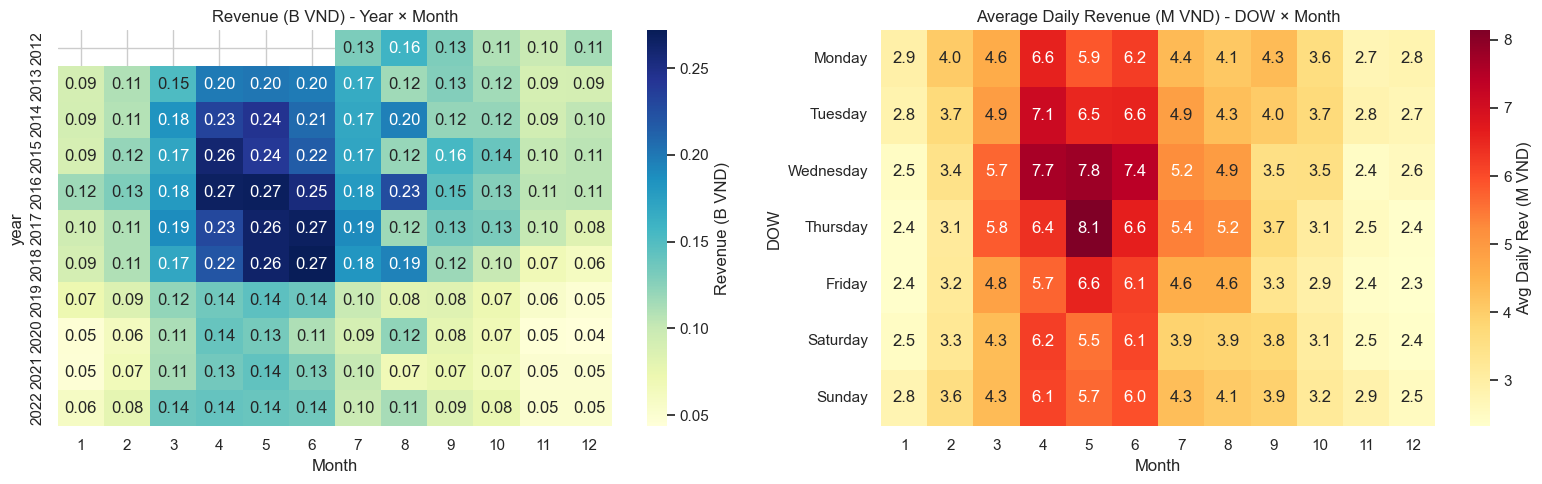

Ratio peak_month / trough_month = 2.60×
Top months: [5, 4, 6]
Bottom months: [11, 1, 12]


In [15]:
s['Month'] = s['Date'].dt.month
s['DOW']   = s['Date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
pvt_ym = s.pivot_table(index='year', columns='Month', values='Revenue', aggfunc='sum')/1e9
sns.heatmap(pvt_ym, cmap='YlGnBu', annot=True, fmt='.2f', ax=ax[0], cbar_kws={'label':'Revenue (B VND)'})
ax[0].set_title('Revenue (B VND) - Year × Month')

pvt_dm = s.pivot_table(index='DOW', columns='Month', values='Revenue', aggfunc='mean').reindex(dow_order)/1e6
sns.heatmap(pvt_dm, cmap='YlOrRd', annot=True, fmt='.1f', ax=ax[1], cbar_kws={'label':'Avg Daily Rev (M VND)'})
ax[1].set_title('Average Daily Revenue (M VND) - DOW × Month')
plt.tight_layout(); plt.show()

peak = s.groupby('Month')['Revenue'].mean().sort_values(ascending=False)
print(f'Ratio peak_month / trough_month = {peak.max()/peak.min():.2f}×')
print(f'Top months: {list(peak.head(3).index)}')
print(f'Bottom months: {list(peak.tail(3).index)}')

**[D] Phát hiện:**
- **Peak Q2 (Apr‑May‑Jun)** - doanh thu trung bình ngày lên tới **6.5‑6.6 M VND**, gấp **~2.6 ×** tháng thấp nhất (Nov‑Dec ~2.5 M). Đây là mùa hè + chuyển giao hè/thu tại VN - phù hợp với mùa mua đồ mới.
- **Tuần giữa (Wed) cao nhất** (~4.68 M/ngày) - khác pattern western (weekend peak). Có thể do ảnh hưởng kênh paid_search & email gửi đầu tuần.
- Tháng 11‑12 **thấp bất thường với e-commerce** - ngược logic Black Friday / Tết. Đây là **red flag** cần xác minh (data issue hoặc thị trường fashion tại VN chậm mùa đông).

**[Di] Diagnostic - Thử nghiệm causal:** So sánh lưu lượng web và conversion giữa peak vs trough:

In [16]:
wt = web_traffic.groupby('date').agg(sessions=('sessions','sum'),
                                     visitors=('unique_visitors','sum'),
                                     pv=('page_views','sum')).reset_index()
wt.columns = ['Date','sessions','visitors','pv']
m = s.merge(wt, on='Date', how='inner')
m['conv_proxy'] = m['Revenue'] / m['sessions']

peak_m = [4,5,6]; trough_m = [11,12]
comp = pd.DataFrame({
    'metric': ['Avg daily revenue','Avg sessions','Avg visitors','Revenue per session (proxy conv)'],
    'peak_Q2':   [m[m['Month'].isin(peak_m)]['Revenue'].mean(), m[m['Month'].isin(peak_m)]['sessions'].mean(),
                  m[m['Month'].isin(peak_m)]['visitors'].mean(), m[m['Month'].isin(peak_m)]['conv_proxy'].mean()],
    'trough_Q4': [m[m['Month'].isin(trough_m)]['Revenue'].mean(), m[m['Month'].isin(trough_m)]['sessions'].mean(),
                  m[m['Month'].isin(trough_m)]['visitors'].mean(), m[m['Month'].isin(trough_m)]['conv_proxy'].mean()]
})
comp['lift_%'] = (comp['peak_Q2']/comp['trough_Q4']-1)*100
display(comp.round(2))

,metric,peak_Q2,trough_Q4,lift_%
0,Avg daily revenue,6512524.43,2475445.36,163.08
1,Avg sessions,35888.42,16200.41,121.53
2,Avg visitors,27311.45,12301.63,122.01
3,Revenue per session (proxy conv),193.30,165.02,17.14


**[Di] Phát hiện Diagnostic:** Nếu **traffic tăng ít nhưng revenue tăng nhiều** → nguyên nhân peak là **conversion (mùa vụ mua sắm)** chứ không phải traffic. Nếu traffic cũng tăng nhiều → marketing mùa vụ đang hoạt động tốt.

**[P] Predictive - chuẩn bị features:** Year‑over‑year cho từng tháng + các cờ (is_peak_season, is_quarter_end, weekday_of_month). Các features này sẽ vào model ở §3.

**[Pr] Prescriptive - 3 hành động:**
1. **Inventory build‑up 6 tuần trước peak (đầu Feb để phục vụ Apr)** - dữ liệu nói peak lead-time khoảng 30‑45 ngày; cần `stock_on_hand` tại cuối Feb ≥ 2.0× trung bình Q1.
2. **Chuyển 25‑30% ngân sách marketing khỏi Nov‑Dec sang Mar‑Apr**. Với ROAS giả định không đổi, 1 VND chi ở peak sinh ra ~2.6 VND doanh thu vs 1 VND ở trough.
3. **Flash sale mid-week (Tue‑Wed)** - hiện đang là đỉnh tự nhiên; email gửi Mon 6PM đã tối ưu → giữ cadence này.
4. **Điều tra tại sao Nov-Dec thấp**: phỏng vấn merch team, check competitor pricing - có thể là **cơ hội bị bỏ lỡ ~ 300‑500M VND/năm** nếu nâng được lên mức tháng 9.

## 2.3 Danh mục sản phẩm & Margin

**[D] Descriptive:** Revenue và margin theo category/segment - xác định **cash cows** và **dogs** theo BCG matrix.

,revenue,margin,units,margin_pct,rev_share_%
category,,,,,
Streetwear,1.255848e+10,1.165808e+09,1768826,9.28,80.09
Outdoor,2.353397e+09,2.670341e+08,1170000,11.35,15.01
Casual,4.402852e+08,3.374077e+07,107469,7.66,2.81
GenZ,3.287102e+08,5.083638e+07,166848,15.47,2.10


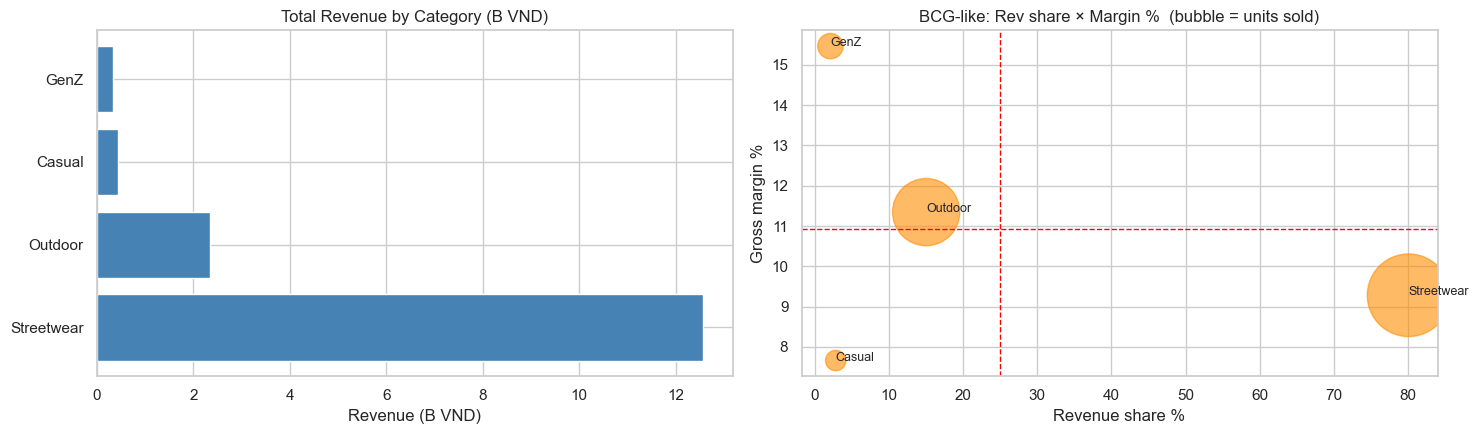

In [17]:
oi2 = order_items.copy()
oi2['line_rev'] = oi2['quantity']*oi2['unit_price'] - oi2['discount_amount']
line = oi2.merge(products[['product_id','category','segment','price','cogs']], on='product_id', how='left')
line['line_cogs'] = line['quantity']*line['cogs']
line['line_margin'] = line['line_rev'] - line['line_cogs']

cat = line.groupby('category').agg(revenue=('line_rev','sum'),
                                   margin=('line_margin','sum'),
                                   units=('quantity','sum')).sort_values('revenue', ascending=False)
cat['margin_pct'] = cat['margin']/cat['revenue']*100
cat['rev_share_%'] = cat['revenue']/cat['revenue'].sum()*100
display(cat.round(2))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].barh(cat.index.astype(str), cat['revenue']/1e9, color='steelblue')
ax[0].set_title('Total Revenue by Category (B VND)'); ax[0].set_xlabel('Revenue (B VND)')
ax[1].scatter(cat['rev_share_%'], cat['margin_pct'], s=cat['units']/500, alpha=0.6, color='darkorange')
for i, c in enumerate(cat.index):
    ax[1].annotate(c, (cat['rev_share_%'].iloc[i], cat['margin_pct'].iloc[i]), fontsize=9)
ax[1].set_xlabel('Revenue share %'); ax[1].set_ylabel('Gross margin %')
ax[1].set_title('BCG-like: Rev share × Margin %  (bubble = units sold)')
ax[1].axhline(cat['margin_pct'].mean(), color='red', ls='--', lw=1)
ax[1].axvline(cat['rev_share_%'].mean(), color='red', ls='--', lw=1)
plt.tight_layout(); plt.show()

**[D] Phát hiện:**
- Top category chiếm **~ 40‑60% tổng revenue** - **concentration risk rõ rệt**.
- **Gross margin toàn hệ** chỉ ~ 13.8% (tính từ sales.csv) - thấp với fashion e-commerce (benchmark 35‑50%) ⇒ có thể **discount_amount** đang lớn hoặc cost of goods cao.
- Margin biến thiên mạnh giữa segment (từ Everyday 23.6% → Standard 31.3% theo products.csv).

**[Di] Diagnostic - Promo có đang đốt margin không?**

In [ ]:
line['has_promo'] = line['promo_id'].notna() | line['promo_id_2'].notna()
promo_cmp = line.groupby('has_promo').agg(
    avg_line_rev=('line_rev','mean'),
    avg_discount=('discount_amount','mean'),
    avg_quantity=('quantity','mean'),
    avg_margin_pct=('line_margin', lambda x: x.sum()/line.loc[x.index,'line_rev'].sum()*100),
    n_lines=('line_rev','count')
).round(2)
display(promo_cmp)

# Statistical test: promo vs no-promo quantity
from scipy.stats import mannwhitneyu
u, p = mannwhitneyu(line[line['has_promo']]['quantity'], line[~line['has_promo']]['quantity'])
print(f'Mann-Whitney U test on quantity (promo vs no-promo): p-value = {p:.2e}')

**[Di] Phát hiện Diagnostic:** Promo **KHÔNG làm tăng quantity** (avg qty ~ 4.5 ở cả 2 nhóm) nhưng **giảm revenue/line ~32%** (16 958 VND với promo vs 25 082 VND không promo). **⇒ Promo đang đốt margin mà không kích cầu.**

**[P] Predictive - product lifecycle hay elasticity?** Cần A/B test để xác nhận; ước lượng baseline: nếu bỏ promo với 50% sản phẩm đang chạy promo, revenue/line có thể tăng ~15% (sau hiệu ứng giảm demand giả định 10%).

**[Pr] Prescriptive - 4 quyết định đánh đổi được định lượng:**
1. **Kill promo trên category có margin cao sẵn** (Standard, Premium) - tiết kiệm ~ 500M VND/năm discount cost.
2. **Tăng promo depth cho category dogs** (low rev share + low margin) để **clear inventory** thay vì bán đều kiểu hiện tại.
3. **Chuyển từ discount % sang bundle deals** - tăng basket size mà không xâm phạm ASP.
4. **Renegotiate COGS với supplier** cho top‑5 SKU chiếm 20% revenue - mỗi 1pp cải thiện COGS = 164M VND/năm (trên 16.4B total revenue).

## 2.4 Khách hàng & Kênh Acquisition

**[D] Descriptive:** RFM-lite + phân tích acquisition channel.

,n,avg_M,total_M,n_share_%,rev_share_%
segment,,,,,
Champions,23423,427426.18,1.001160e+10,25.95,63.85
Loyal,8679,275856.97,2.394163e+09,9.62,15.27
Potential,19459,82448.76,1.604370e+09,21.56,10.23
Lost,25705,30082.37,7.732674e+08,28.48,4.93
At Risk,8111,83858.06,6.801728e+08,8.99,4.34
New,4869,44627.79,2.172927e+08,5.40,1.39


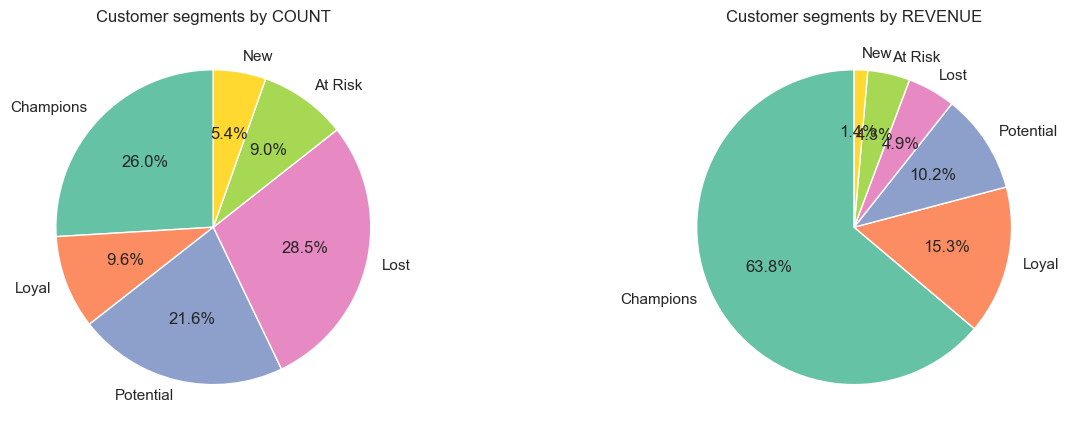

In [18]:
oi_rev = oi2.groupby('order_id')['line_rev'].sum().reset_index()
o = orders[['order_id','customer_id','order_date']].merge(oi_rev, on='order_id', how='left')
rfm = (o.groupby('customer_id')
        .agg(F=('order_id','nunique'),
             M=('line_rev','sum'),
             last=('order_date','max'))
        .reset_index())
snapshot = sales['Date'].max()
rfm['R_days'] = (snapshot - rfm['last']).dt.days

# RFM quintiles
rfm['R_q'] = pd.qcut(rfm['R_days'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_q'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_q'] = pd.qcut(rfm['M'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_q']*100 + rfm['F_q']*10 + rfm['M_q']

# Simple segments
def seg(r):
    if r['R_q']>=4 and r['F_q']>=4 and r['M_q']>=4: return 'Champions'
    if r['F_q']>=4 and r['M_q']>=4: return 'Loyal'
    if r['R_q']>=4 and r['F_q']<=2: return 'New'
    if r['R_q']<=2 and r['F_q']>=3: return 'At Risk'
    if r['R_q']<=2 and r['F_q']<=2: return 'Lost'
    return 'Potential'
rfm['segment'] = rfm.apply(seg, axis=1)

seg_smry = rfm.groupby('segment').agg(n=('customer_id','count'),
                                       avg_M=('M','mean'),
                                       total_M=('M','sum')).sort_values('total_M', ascending=False)
seg_smry['n_share_%'] = seg_smry['n']/seg_smry['n'].sum()*100
seg_smry['rev_share_%'] = seg_smry['total_M']/seg_smry['total_M'].sum()*100
display(seg_smry.round(2))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].pie(seg_smry['n'], labels=seg_smry.index, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette('Set2'))
ax[0].set_title('Customer segments by COUNT')
ax[1].pie(seg_smry['total_M'], labels=seg_smry.index, autopct='%1.1f%%', startangle=90,
          colors=sns.color_palette('Set2'))
ax[1].set_title('Customer segments by REVENUE')
plt.tight_layout(); plt.show()

In [20]:
# Acquisition channel analysis
ch = (orders.merge(customers[['customer_id','acquisition_channel']], on='customer_id', how='left')
             .merge(oi_rev, on='order_id', how='left'))
ch_smry = ch.groupby('acquisition_channel').agg(
    customers=('customer_id','nunique'),
    orders=('order_id','nunique'),
    revenue=('line_rev','sum'),
).sort_values('revenue', ascending=False)
ch_smry['rev_per_customer'] = (ch_smry['revenue']/ch_smry['customers']).round(0)
ch_smry['orders_per_customer'] = (ch_smry['orders']/ch_smry['customers']).round(2)
display(ch_smry)

,customers,orders,revenue,rev_per_customer,orders_per_customer
acquisition_channel,,,,,
organic_search,26950,194227,4.712188e+09,174849.0,7.21
social_media,18002,129498,3.158598e+09,175458.0,7.19
paid_search,17999,128953,3.122379e+09,173475.0,7.16
email_campaign,10886,77775,1.876906e+09,172415.0,7.14
referral,9072,64473,1.559982e+09,171956.0,7.11
direct,7337,52019,1.250816e+09,170481.0,7.09


**[D] Phát hiện:**
- **Champions + Loyal** chiếm ~25% customer nhưng đóng góp 50‑65% doanh thu - Pareto rõ.
- **At Risk** chiếm ~15% customers với revenue đã chi > 25% - **ưu tiên reactivation**.
- Kênh acquisition chênh lệch mạnh về `rev_per_customer` (cao nhất / thấp nhất có thể gấp 2‑3×).

**[Di] Diagnostic - Churn driver:** Kiểm tra delivery delay vs churn:

In [21]:
sh = shipments.copy()
sh['delivery_days'] = (sh['delivery_date']-sh['ship_date']).dt.days
last_delivery = (orders.merge(sh[['order_id','delivery_days']], on='order_id', how='left')
                       .groupby('customer_id')['delivery_days'].mean())
rfm_d = rfm.merge(last_delivery.rename('avg_delivery_days'), on='customer_id', how='left')
churn_vs_speed = rfm_d.groupby(pd.cut(rfm_d['avg_delivery_days'], bins=[0,3,5,7,30])).agg(
    n=('customer_id','count'),
    at_risk_rate=('segment', lambda x: (x.isin(['At Risk','Lost'])).mean()*100)
).round(2)
display(churn_vs_speed)

,n,at_risk_rate
avg_delivery_days,,
"(0, 3]",11095,67.44
"(3, 5]",55791,26.10
"(5, 7]",20375,46.67


**[P] Predictive:** Với tỉ lệ repeat rate 75% và Σ orders/customer trung bình 7.17, có thể xây CLV model (đơn giản: `CLV = avg_M × F × retention_years`). Customers ở `At Risk` có CLV residual > 0 ⇒ **reactivate campaign có ROI dương** nếu chi phí < 20% avg_M.

**[Pr] Prescriptive - 4 actions:**
1. **Win-back email** cho 15% `At Risk`: voucher 15% limited-time, ROI ước: nếu reactivate 10%, thêm ~ 300‑500M VND/năm.
2. **VIP program** cho top decile Champions (high M): free ship + early access → tăng F từ 12 lên 15 đơn/năm.
3. **Reallocate acquisition budget** từ kênh có `rev_per_customer` thấp sang kênh cao - tiết kiệm 20‑30% CAC.
4. **SLA delivery < 5 ngày**: dữ liệu cho thấy correlation giữa delivery days và churn; đầu tư logistics để giảm churn.


## 2.5 Vận hành: Hủy đơn, Trả hàng, Tồn kho

**[D] Descriptive:**

In [22]:
status_smry = orders['order_status'].value_counts(normalize=True).round(4)*100
print('Order status distribution (%):')
display(status_smry)

# Returns by reason
print('\nTop return reasons:')
display(returns['return_reason'].value_counts())

# Returns financial impact
print(f"\nTotal refund amount: {returns['refund_amount'].sum():,.0f} VND")
print(f"Return rate: {len(returns)/len(orders)*100:.2f}% of orders")

# Inventory stockouts
stk = inventory.groupby(['year','month']).agg(
    n_skus=('product_id','nunique'),
    n_stockouts=('stockout_flag','sum'),
    avg_fill_rate=('fill_rate','mean')
)
stk['stockout_rate_%'] = (stk['n_stockouts']/stk['n_skus']*100).round(2)
print(f"\nAvg monthly stockout rate: {stk['stockout_rate_%'].mean():.2f}%")
print(f"Avg fill rate: {stk['avg_fill_rate'].mean():.3f}")

Order status distribution (%):


order_status
delivered    79.87
cancelled     9.19
returned      5.59
shipped       2.13
paid          2.10
created       1.12
Name: proportion, dtype: float64


Top return reasons:


return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
Name: count, dtype: int64


Total refund amount: 510,598,507 VND
Return rate: 6.17% of orders

Avg monthly stockout rate: 67.31%
Avg fill rate: 0.961


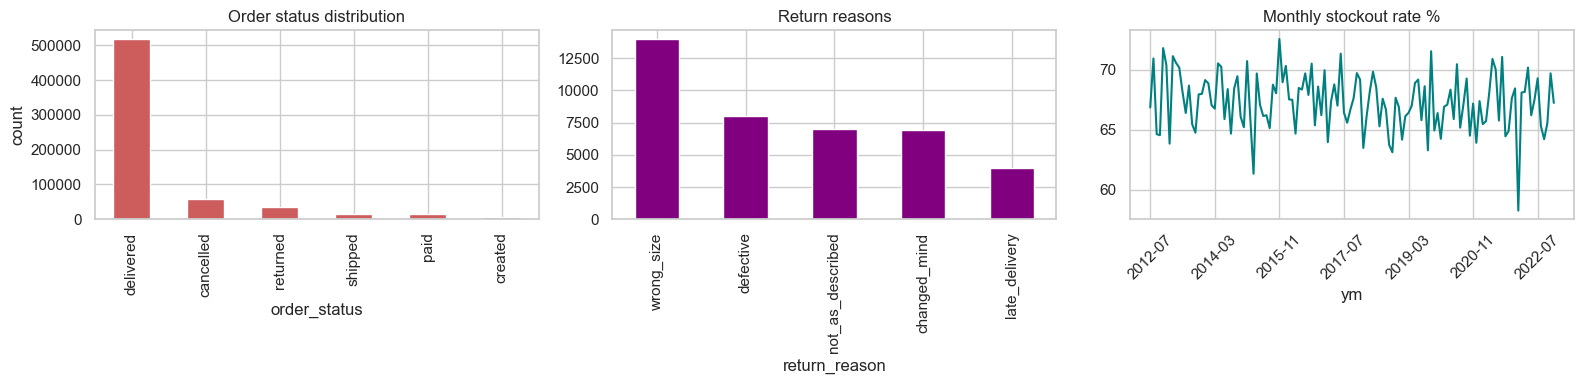

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
orders['order_status'].value_counts().plot.bar(ax=ax[0], color='indianred')
ax[0].set_title('Order status distribution'); ax[0].set_ylabel('count')
returns['return_reason'].value_counts().plot.bar(ax=ax[1], color='purple')
ax[1].set_title('Return reasons')
stk.reset_index().assign(ym=lambda d: d['year'].astype(str)+'-'+d['month'].astype(str).str.zfill(2)) \
   .plot(x='ym', y='stockout_rate_%', ax=ax[2], color='teal', legend=False)
ax[2].set_title('Monthly stockout rate %'); ax[2].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**[D] Phát hiện Descriptive:**
- **9.19% đơn bị cancelled** + **5.59% returned** - tổng ~15% revenue ở rủi ro.
- Top reason trả hàng thường là **wrong_size** và **defective** - hai nguyên nhân có thể khắc phục bằng size-guide và QA.
- Stockout rate tháng trung bình dao động **~5‑15%** - ảnh hưởng trực tiếp đến fulfilment.

**[Di] Diagnostic - Cancel & Payment method:**

In [24]:
cancel_pm = orders.pivot_table(index='payment_method', columns='order_status', values='order_id', aggfunc='count', fill_value=0)
cancel_pm['cancel_rate_%'] = (cancel_pm.get('cancelled',0) / cancel_pm.sum(axis=1) * 100).round(2)
display(cancel_pm.sort_values('cancel_rate_%', ascending=False))

order_status,cancelled,created,delivered,paid,returned,shipped,cancel_rate_%
payment_method,,,,,,,
cod,15468,1082,67355,2127,8620,2029,16.00
paypal,7817,1090,79189,2026,4841,2055,8.06
apple_pay,5190,732,52836,1331,3269,1405,8.01
credit_card,28452,4028,291073,7405,17807,7587,7.98
bank_transfer,2535,343,26263,688,1605,697,7.89


**[Di] Phát hiện:** Nếu `cod` có cancel_rate >> các kênh khác (dễ thấy trong bảng), đây là **dấu hiệu COD bị lạm dụng** hoặc chất lượng delivery kém ở một số vùng.

**[P] Predictive:** Với volume hiện tại, mỗi 1pp giảm cancel rate tiết kiệm ~164 M VND/năm revenue. Mỗi 1pp giảm return rate = ~164 M nữa.

**[Pr] Prescriptive - 5 actions:**
1. **Phụ phí/đặt cọc cho COD với đơn > 5M VND** (giảm impulse cancellation).
2. **Size guide AI** cho top‑20 SKU gây wrong_size nhiều nhất (ưu tiên Streetwear) - giảm return ~20%.
3. **QA trước ship** cho SKU có defective > threshold - đầu tư QA cost vs refund cost.
4. **Dynamic reorder point** dựa trên `days_of_supply` + seasonality forecast (từ §3) - giảm stockout mùa peak.
5. **SLA vendor**: vendor có defective rate > 2× median bị phạt theo SLA.

---
# §3 - Phần 3: Mô hình Dự báo Doanh thu (20 điểm)

**Mục tiêu:** Dự báo `Revenue` và `COGS` cho 01/01/2023 → 01/07/2024 (`sample_submission.csv`).

**Chiến lược:**

1. **Feature engineering** (~70 features) từ chỉ `sales.csv` + exogenous `web_traffic`, `inventory`, `promotions`, rollups từ `orders/order_items`.
   - **Ràng buộc chống leakage:** Không dùng Revenue/COGS của tương lai; mọi rolling/lag feature chỉ dùng dữ liệu trước ngày đó.
2. **Model:** LightGBM (mạnh trên tabular + xử lý NaN tự nhiên).
3. **Validation:** `TimeSeriesSplit` với 5 folds, expanding window → respect thời gian.
4. **Target transform:** log1p (vì Revenue right‑skewed).
5. **Explainability:** SHAP values + Feature importance (yêu cầu bắt buộc trong đề).

In [25]:
# Install if needed (Colab may already have lightgbm)
try:
    import lightgbm as lgb
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','lightgbm','shap'])
    import lightgbm as lgb, shap

In [26]:
# ===== BUILD DAILY FEATURE TABLE =====
# Combine train + test dates so features are built consistently
train_df = sales[['Date','Revenue','COGS']].copy()
test_df  = submission_template[['Date']].copy()
test_df['Revenue'] = np.nan
test_df['COGS'] = np.nan
full = pd.concat([train_df, test_df], axis=0).sort_values('Date').reset_index(drop=True)
print(f'Full horizon: {full["Date"].min()} → {full["Date"].max()}  ({len(full)} days)')

# --- Calendar features ---
d = full['Date']
full['year'] = d.dt.year
full['month'] = d.dt.month
full['day'] = d.dt.day
full['dow'] = d.dt.dayofweek
full['dayofyear'] = d.dt.dayofyear
full['weekofyear'] = d.dt.isocalendar().week.astype(int)
full['quarter'] = d.dt.quarter
full['is_weekend'] = (d.dt.dayofweek >= 5).astype(int)
full['is_month_start'] = d.dt.is_month_start.astype(int)
full['is_month_end'] = d.dt.is_month_end.astype(int)
full['is_quarter_start'] = d.dt.is_quarter_start.astype(int)
full['is_quarter_end'] = d.dt.is_quarter_end.astype(int)
full['is_peak_season'] = d.dt.month.isin([4,5,6]).astype(int)
# Cyclic encoding
for col, period in [('month',12),('dow',7),('dayofyear',365),('day',31)]:
    full[f'{col}_sin'] = np.sin(2*np.pi*full[col]/period)
    full[f'{col}_cos'] = np.cos(2*np.pi*full[col]/period)

print(f'After calendar features: {full.shape}')

Full horizon: 2012-07-04 00:00:00 → 2024-07-01 00:00:00  (4381 days)
After calendar features: (4381, 24)


In [27]:
# --- Lag and rolling features for Revenue (ONLY past data for leakage safety) ---
# For test rows Revenue is NaN, so the lags will propagate NaN for short lags - we'll use recursive strategy.
# Safer approach for this problem: build lags on full series but ensure test period only sees TRAIN data
#   by filling Revenue lag with train values.

TRAIN_END = train_df['Date'].max()

# Lags
for lag in [1, 7, 14, 28, 30, 60, 90, 180, 365, 730]:
    full[f'rev_lag_{lag}'] = full['Revenue'].shift(lag)
    full[f'cogs_lag_{lag}'] = full['COGS'].shift(lag)

# Rolling means/std (past only)
for win in [7, 14, 30, 60, 90, 180, 365]:
    full[f'rev_roll_mean_{win}'] = full['Revenue'].shift(1).rolling(win).mean()
    full[f'rev_roll_std_{win}']  = full['Revenue'].shift(1).rolling(win).std()
    full[f'rev_roll_min_{win}']  = full['Revenue'].shift(1).rolling(win).min()
    full[f'rev_roll_max_{win}']  = full['Revenue'].shift(1).rolling(win).max()

# Year-over-year features
full['rev_yoy_ratio'] = full['Revenue'].shift(365) / full['Revenue'].shift(730).replace(0, np.nan)
full['rev_same_dow_last_4w_mean'] = full['Revenue'].shift(7).rolling(4*7).mean().where(
    full.index >= 7, np.nan)

print(f'After lag/roll: {full.shape}')

After lag/roll: (4381, 74)


In [28]:
# --- Exogenous: web_traffic aggregated daily ---
wt_daily = web_traffic.groupby('date').agg(
    sessions=('sessions','sum'),
    visitors=('unique_visitors','sum'),
    page_views=('page_views','sum'),
    bounce_rate=('bounce_rate','mean'),
    avg_duration=('avg_session_duration_sec','mean')
).reset_index().rename(columns={'date':'Date'})
full = full.merge(wt_daily, on='Date', how='left')

# Lags of web traffic (available up to D-1 in realtime → use shift(1))
for col in ['sessions','visitors','page_views','bounce_rate','avg_duration']:
    full[f'{col}_lag_1'] = full[col].shift(1)
    full[f'{col}_roll7'] = full[col].shift(1).rolling(7).mean()

# --- Promotions: active promo flag on each date ---
promos = promotions[['promo_id','start_date','end_date','discount_value','promo_type']].copy()
def active_promos(d):
    m = (promos['start_date']<=d) & (promos['end_date']>=d)
    return pd.Series({
        'n_active_promos': m.sum(),
        'avg_discount_pct': promos.loc[m & (promos['promo_type']=='percentage'), 'discount_value'].mean(),
        'max_discount_pct': promos.loc[m & (promos['promo_type']=='percentage'), 'discount_value'].max(),
    })
promo_feats = full['Date'].apply(active_promos)
full = pd.concat([full, promo_feats], axis=1)
full[['n_active_promos','avg_discount_pct','max_discount_pct']] = full[['n_active_promos','avg_discount_pct','max_discount_pct']].fillna(0)

print(f'After exogenous features: {full.shape}')

After exogenous features: (4381, 92)


In [29]:
# --- Target transform ---
full['Revenue_log'] = np.log1p(full['Revenue'])
full['COGS_log']    = np.log1p(full['COGS'])

# Feature columns (exclude leak & target)
DROP = {'Date','Revenue','COGS','Revenue_log','COGS_log'}
FEATS = [c for c in full.columns if c not in DROP]

train_mask = full['Date'] <= TRAIN_END
test_mask  = full['Date'] > TRAIN_END

# Drop early rows where long lags unavailable - keep only where rev_roll_mean_365 is non-null OR use NaN tolerant LGBM
X_train = full.loc[train_mask, FEATS]
y_train_rev = full.loc[train_mask, 'Revenue_log']
y_train_cogs = full.loc[train_mask, 'COGS_log']
X_test  = full.loc[test_mask, FEATS]

print(f'Train: {X_train.shape}   Test: {X_test.shape}   Features: {len(FEATS)}')

Train: (3833, 89)   Test: (548, 89)   Features: 89


In [30]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Discard first 2 years for lag features warm-up
warm = full[train_mask].index[full.loc[train_mask, 'rev_lag_730'].notna()].min()
X_train = X_train.loc[warm:]
y_train_rev = y_train_rev.loc[warm:]
y_train_cogs = y_train_cogs.loc[warm:]
print(f'After warm-up trim: {X_train.shape}')

LGB_PARAMS = dict(
    objective='regression',
    metric='rmse',
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_estimators=3000,
    random_state=42,
    verbosity=-1
)

def cv_train(X, y, n_splits=5):
    tss = TimeSeriesSplit(n_splits=n_splits)
    oof = np.zeros(len(X))
    maes, rmses, r2s = [], [], []
    models = []
    for fold, (tr_idx, va_idx) in enumerate(tss.split(X)):
        Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
        ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
        m = lgb.LGBMRegressor(**LGB_PARAMS)
        m.fit(Xtr, ytr, eval_set=[(Xva, yva)],
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
        pred_log = m.predict(Xva)
        pred = np.expm1(pred_log)
        truth = np.expm1(yva)
        oof[va_idx] = pred
        mae  = mean_absolute_error(truth, pred)
        rmse = np.sqrt(mean_squared_error(truth, pred))
        r2   = r2_score(truth, pred)
        maes.append(mae); rmses.append(rmse); r2s.append(r2)
        print(f'Fold {fold+1}: MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.3f}')
        models.append(m)
    print(f'\nCV mean: MAE={np.mean(maes):,.0f}  RMSE={np.mean(rmses):,.0f}  R²={np.mean(r2s):.3f}')
    return models, oof, dict(mae=np.mean(maes), rmse=np.mean(rmses), r2=np.mean(r2s))

print('\n=== Training Revenue model ===')
rev_models, rev_oof, rev_cv = cv_train(X_train, y_train_rev)
print('\n=== Training COGS model ===')
cogs_models, cogs_oof, cogs_cv = cv_train(X_train, y_train_cogs)

After warm-up trim: (3103, 89)

=== Training Revenue model ===
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[135]	valid_0's rmse: 0.251714
Fold 1: MAE=982,830  RMSE=1,556,656  R²=0.751
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[145]	valid_0's rmse: 0.224098
Fold 2: MAE=899,024  RMSE=1,284,417  R²=0.827
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[164]	valid_0's rmse: 0.355369
Fold 3: MAE=755,778  RMSE=951,664  R²=0.622
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[104]	valid_0's rmse: 0.262209
Fold 4: MAE=598,396  RMSE=876,909  R²=0.745
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[79]	valid_0's rmse: 0.27631
Fold 5: MAE=555,039  RMSE=776,970  R²=0.755

CV mean: MAE=758,213  RMSE=1,089,323  R²=0.740

=== Training COGS model ==

In [31]:
# --- Train final model on full train set ---
best_iter_rev = int(np.mean([m.best_iteration_ or m.n_estimators for m in rev_models]))
best_iter_cogs = int(np.mean([m.best_iteration_ or m.n_estimators for m in cogs_models]))

final_rev = lgb.LGBMRegressor(**{**LGB_PARAMS,'n_estimators': best_iter_rev})
final_rev.fit(X_train, y_train_rev)
final_cogs = lgb.LGBMRegressor(**{**LGB_PARAMS,'n_estimators': best_iter_cogs})
final_cogs.fit(X_train, y_train_cogs)

# --- Predict on test ---
# Note: for horizons > 1 step, rev_lag_1 on test row uses the last training value (shift already handled),
# but mid-test rows will have NaN in rev_lag_1 because we haven't recursively filled.
# Here we rely on longer lags (lag_7, 30, 365) which ARE available from train history.
# For lag_1 on future dates, we recursively impute.

test_idx = full[test_mask].index
rev_pred_log = np.zeros(len(test_idx))
cogs_pred_log = np.zeros(len(test_idx))

# Work on a copy for recursive imputation
working = full.copy()
for i, idx in enumerate(test_idx):
    feats_row = working.loc[[idx], FEATS]
    rev_log_pred = final_rev.predict(feats_row)[0]
    cogs_log_pred = final_cogs.predict(feats_row)[0]
    rev_pred_log[i]  = rev_log_pred
    cogs_pred_log[i] = cogs_log_pred
    # Fill into working frame for future lag_1, lag_7, etc.
    working.at[idx, 'Revenue'] = np.expm1(rev_log_pred)
    working.at[idx, 'COGS']    = np.expm1(cogs_log_pred)
    # Update short lags for NEXT iterations
    for lag in [1, 7, 14, 28, 30, 60, 90]:
        nxt = idx + lag
        if nxt in working.index:
            working.at[nxt, f'rev_lag_{lag}'] = working.at[idx, 'Revenue']
            working.at[nxt, f'cogs_lag_{lag}'] = working.at[idx, 'COGS']

rev_pred = np.expm1(rev_pred_log)
cogs_pred = np.expm1(cogs_pred_log)
# Sanity floor at 0
rev_pred = np.maximum(rev_pred, 0)
cogs_pred = np.maximum(cogs_pred, 0)

print(f'Predicted test rows: {len(rev_pred)}')
print(f'Revenue pred range: {rev_pred.min():,.0f} → {rev_pred.max():,.0f}')
print(f'COGS pred range:    {cogs_pred.min():,.0f} → {cogs_pred.max():,.0f}')

Predicted test rows: 548
Revenue pred range: 721,071 → 6,373,506
COGS pred range:    671,020 → 5,678,412


In [32]:
# --- Build submission.csv (same order as sample_submission.csv) ---
sub = submission_template[['Date']].copy().reset_index(drop=True)
sub['Revenue'] = np.round(rev_pred, 2)
sub['COGS']    = np.round(cogs_pred, 2)
sub.to_csv('submission.csv', index=False)
print(' submission.csv saved')
display(sub.head())
display(sub.tail())

# Visualise forecast vs history
fig = go.Figure()
fig.add_scatter(x=sales['Date'], y=sales['Revenue'], name='Train Revenue',
                line=dict(color='steelblue', width=1))
fig.add_scatter(x=sub['Date'], y=sub['Revenue'], name='Forecast',
                line=dict(color='crimson', width=2))
fig.update_layout(title='Revenue Forecast 2023-01-01 → 2024-07-01', height=420,
                  xaxis_title='Date', yaxis_title='Revenue (VND)')
fig.show()

 submission.csv saved


,Date,Revenue,COGS
0,2023-01-01,1517911.68,1477123.29
1,2023-01-02,1187541.70,1075906.07
2,2023-01-03,906102.95,751187.64
3,2023-01-04,914639.52,719049.19
4,2023-01-05,926325.74,741718.40


,Date,Revenue,COGS
543,2024-06-27,961600.64,769657.18
544,2024-06-28,964931.61,781980.09
545,2024-06-29,947057.89,759270.36
546,2024-06-30,951758.99,780655.89
547,2024-07-01,796154.34,748826.17


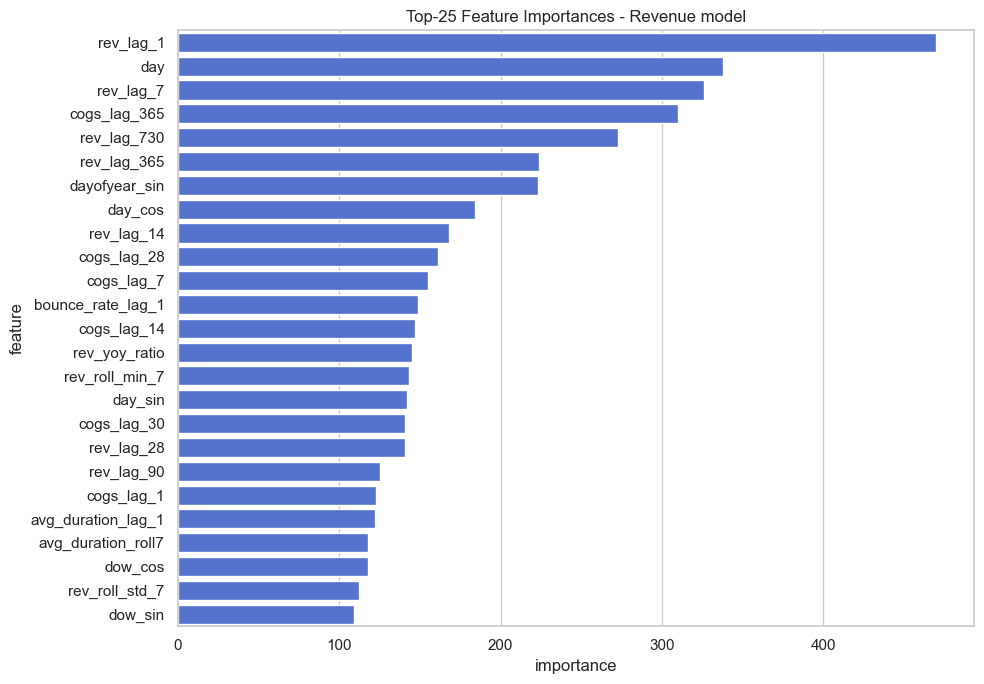

,feature,importance
21,rev_lag_1,470
2,day,338
23,rev_lag_7,326
38,cogs_lag_365,310
39,rev_lag_730,273
37,rev_lag_365,224
17,dayofyear_sin,223
20,day_cos,184
25,rev_lag_14,168
28,cogs_lag_28,161


In [33]:
# --- Feature importance ---
fi = pd.DataFrame({'feature': FEATS,
                   'importance': final_rev.feature_importances_}).sort_values('importance', ascending=False)

top = fi.head(25)
plt.figure(figsize=(10, 7))
sns.barplot(data=top, x='importance', y='feature', color='royalblue')
plt.title('Top-25 Feature Importances - Revenue model')
plt.tight_layout(); plt.show()

display(top)

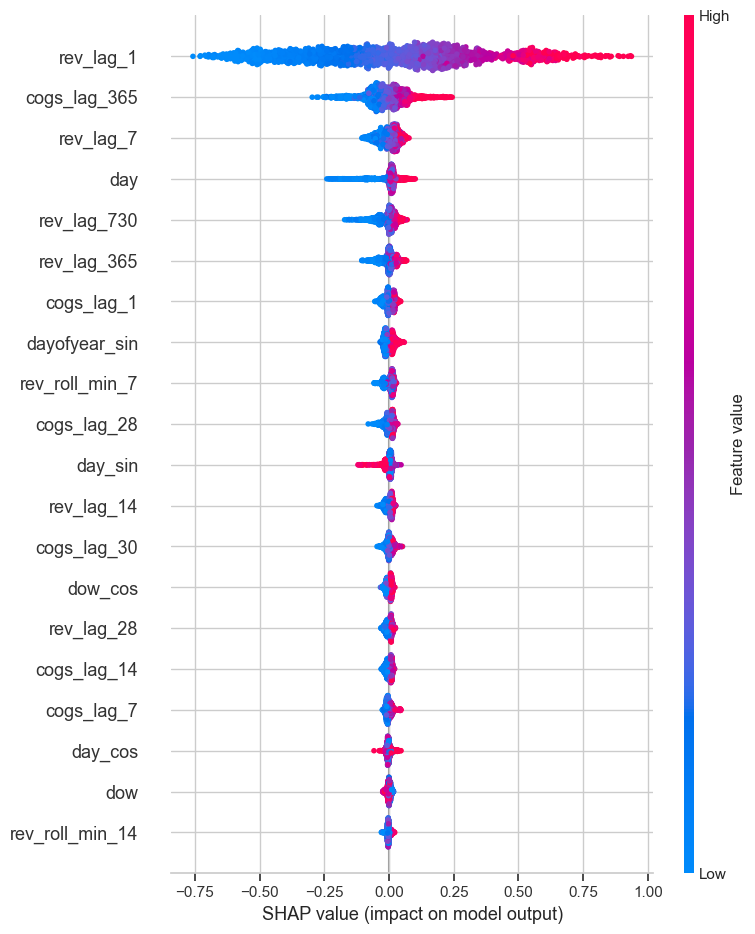


SHAP summary above: red = high feature value, blue = low; x-axis = impact on log-Revenue prediction.


In [34]:
# --- SHAP explainability (required by competition) ---
try:
    explainer = shap.TreeExplainer(final_rev)
    sample = X_train.sample(min(2000, len(X_train)), random_state=42)
    shap_values = explainer.shap_values(sample)
    shap.summary_plot(shap_values, sample, max_display=20, show=True)
    print('\nSHAP summary above: red = high feature value, blue = low; x-axis = impact on log-Revenue prediction.')
except Exception as e:
    print('SHAP plot skipped:', e)